In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets
sentiment = pd.read_csv('D:/Task submission/fear_greed_index.csv')
trades = pd.read_csv('D:/Task submission/historical_data.csv')


print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
# Clean column names (remove spaces, lowercase)
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

print(trades.columns)
print(sentiment.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [6]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

In [7]:
merged = pd.merge(trades, sentiment, on='date', how='left')

print(merged[['date', 'classification']].head())

         date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed


In [8]:
clean = merged.copy()

# Optional: drop useless columns
clean = clean[['account', 'coin', 'execution_price', 'size_usd',
               'side', 'closed_pnl', 'fee', 'classification', 'date']]

In [9]:
clean['closed_pnl'] = pd.to_numeric(clean['closed_pnl'], errors='coerce')
clean['size_usd'] = pd.to_numeric(clean['size_usd'], errors='coerce')
clean['fee'] = pd.to_numeric(clean['fee'], errors='coerce')

In [10]:
clean = clean[clean['closed_pnl'] != 0]

In [11]:
print(clean.groupby('classification')['closed_pnl'].mean())

classification
Extreme Fear      71.027316
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Name: closed_pnl, dtype: float64


In [12]:
clean.groupby('classification')['closed_pnl'].agg(['mean','median','std','count'])

,mean,median,std,count
classification,,,,
Extreme Fear,71.027316,6.388050,1628.408341,10406
Extreme Greed,130.205309,8.530740,1058.126139,20853
Fear,112.625988,6.350483,1344.778427,29808
Greed,85.403927,4.927600,1576.394764,25176
Neutral,71.199993,4.583458,743.212863,18159


In [13]:
print(clean.groupby('classification')['size_usd'].mean())

classification
Extreme Fear     5467.570419
Extreme Greed    2779.563632
Fear             8041.140445
Greed            5438.671764
Neutral          5556.444833
Name: size_usd, dtype: float64


In [14]:
print(clean.groupby(['classification', 'side'])['closed_pnl'].mean())

classification  side
Extreme Fear    BUY     119.450350
                SELL     50.263189
Extreme Greed   BUY      28.977039
                SELL    176.048252
Fear            BUY     209.650427
                SELL     69.106910
Greed           BUY      54.170553
                SELL    111.015159
Neutral         BUY      94.593942
                SELL     60.050869
Name: closed_pnl, dtype: float64


In [15]:
print(clean.groupby('classification')['fee'].mean())

classification
Extreme Fear     1.175307
Extreme Greed    0.655343
Fear             1.576732
Greed            1.178809
Neutral          1.225987
Name: fee, dtype: float64


In [16]:
clean['win'] = clean['closed_pnl'] > 0
performance = clean.groupby('classification').agg({
    'win': 'mean',
    'closed_pnl': ['mean','median'],
    'size_usd': 'mean'
})

print(performance)

                     win  closed_pnl               size_usd
                    mean        mean    median         mean
classification                                             
Extreme Fear    0.762156   71.027316  6.388050  5467.570419
Extreme Greed   0.891670  130.205309  8.530740  2779.563632
Fear            0.872886  112.625988  6.350483  8041.140445
Greed           0.768907   85.403927  4.927600  5438.671764
Neutral         0.823889   71.199993  4.583458  5556.444833


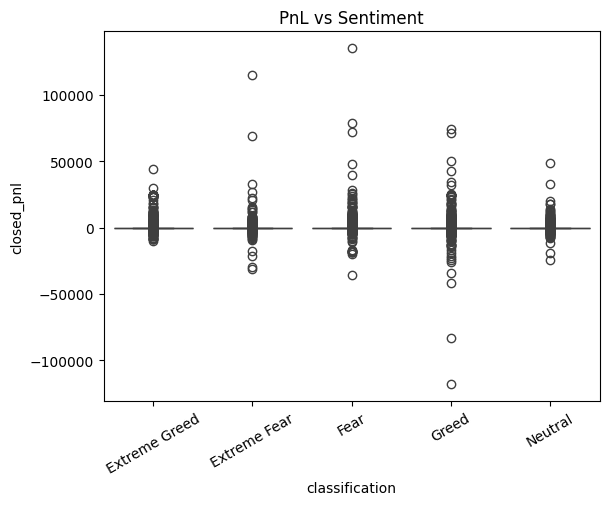

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=clean)
plt.title("PnL vs Sentiment")
plt.xticks(rotation=30)
plt.show()

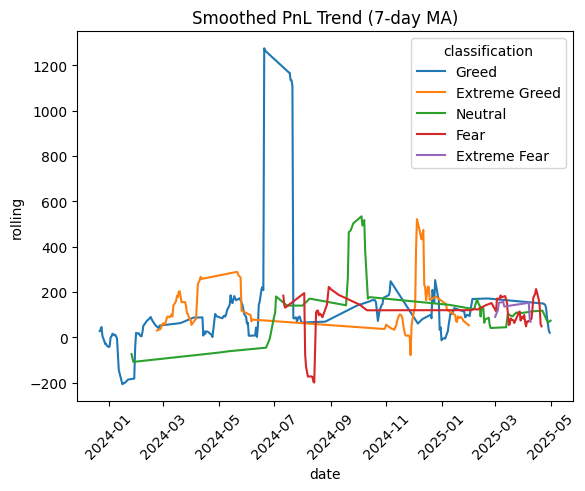

In [18]:
daily = clean.groupby(['date','classification'])['closed_pnl'].mean().reset_index()

daily['rolling'] = daily.groupby('classification')['closed_pnl']\
                        .transform(lambda x: x.rolling(7).mean())

sns.lineplot(data=daily, x='date', y='rolling', hue='classification')
plt.title('Smoothed PnL Trend (7-day MA)')
plt.xticks(rotation=45)
plt.show()

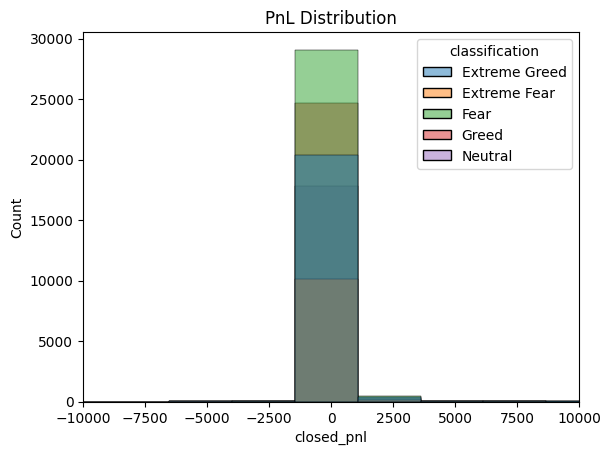

In [19]:
sns.histplot(data=clean, x='closed_pnl', hue='classification', bins=100)
plt.xlim(-10000, 10000)  # zoom into useful region
plt.title('PnL Distribution')
plt.show()

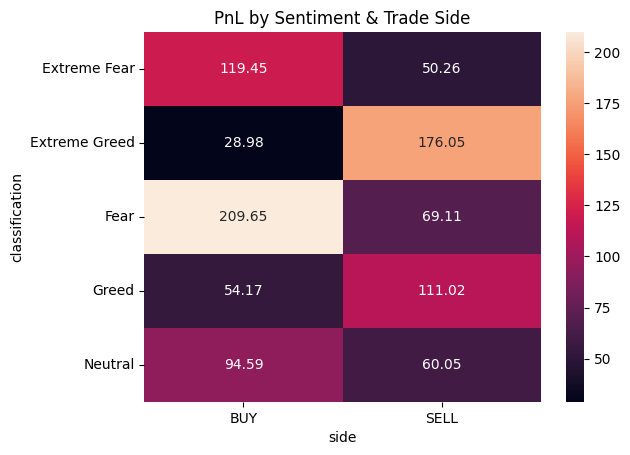

In [20]:
pivot = clean.pivot_table(values='closed_pnl', 
                          index='classification', 
                          columns='side', 
                          aggfunc='mean')

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title('PnL by Sentiment & Trade Side')
plt.show()